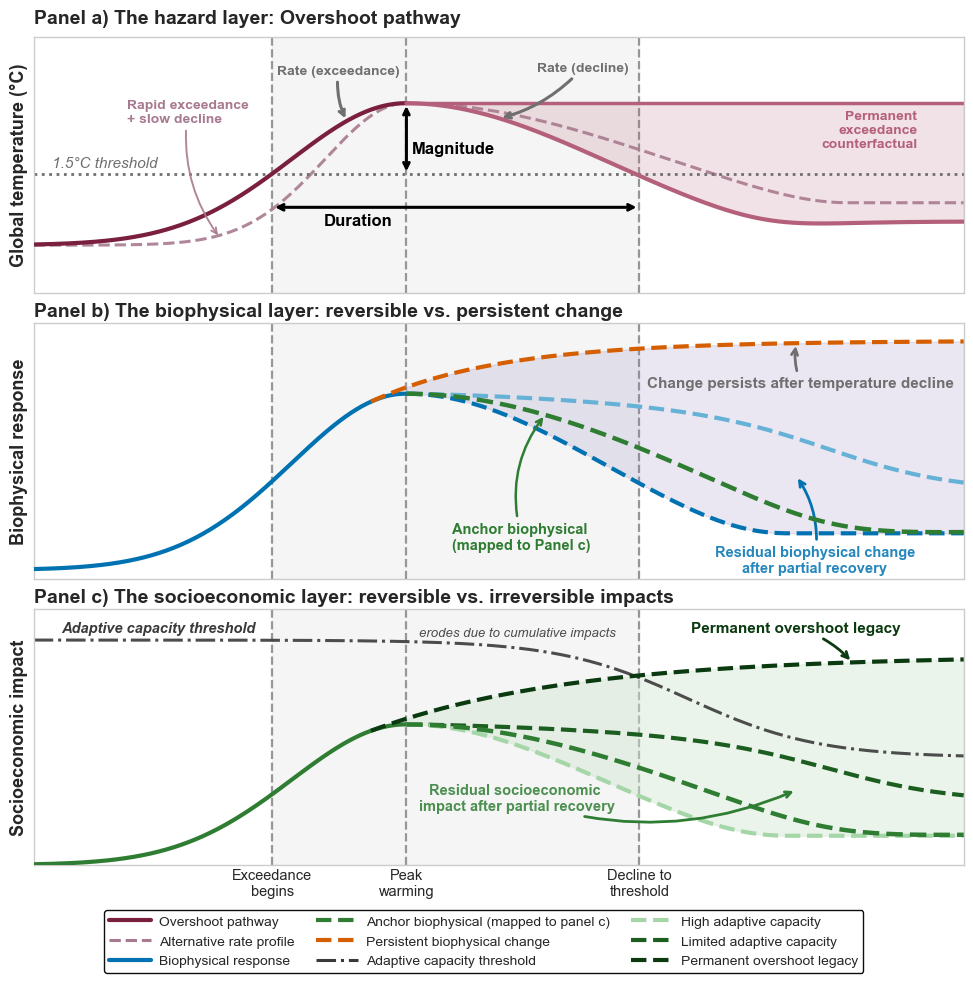

saved


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.style.use('seaborn-v0_8-whitegrid')

# === COLOURS ===
COL_FORCING       = '#7a1f3d'
COL_FORCING_LIGHT = '#b5607a'
COL_FORCING_FILL  = '#b5607a'
COL_ALT           = '#a87a8f'   

COL_SOLID         = '#0072B2'   
COL_DELAYED       = '#66b2d6'   
COL_ANCHOR_GREEN  = '#2E7D32'   
COL_UPPER         = '#D55E00'   

COL_C_FAST        = '#a5d6a7'   
COL_C_CONV        = COL_ANCHOR_GREEN  
COL_C_NOCONV      = '#1B5E20'   
COL_C_IRREV       = '#0b3a10'   

COL_FILL          = '#8B7DB8'   
COL_C_FILL        = '#d3e7d3'   
COL_SHADE         = '#d9d9d9'
COL_GREY          = '#6f6f6f'
COL_THRESHOLD     = '#3a3a3a'


def smoothstep(x):
    x = np.clip(x, 0, 1)
    return x * x * (3 - 2 * x)


def saturating_from_slope(tseg, t0, y0, m0, ymax):
    """
    Smooth saturating curve starting at (t0, y0), with initial slope m0,
    approaching ymax asymptotically.
    Form: y = ymax - (ymax - y0) * exp(-k * (t - t0))
    where k is chosen so that dy/dt at t0 equals m0.
    """
    A = ymax - y0
    k = m0 / A if A > 1e-12 else 0.0
    return ymax - A * np.exp(-k * (tseg - t0))


# === TIME AXIS AND CENTRAL TRAJECTORY ===
t = np.linspace(0, 100, 500)
peak_time = 40
target_temp = 1.5
baseline = 1.2
amplitude = 0.6
sigma2_left = 300
sigma2_right = 902

exponent = np.where(
    t <= peak_time,
    -(t - peak_time)**2 / sigma2_left,
    -(t - peak_time)**2 / sigma2_right
)
gmst_raw = baseline + amplitude * np.exp(exponent)

# Milestones from gmst_raw — gives ascent width < decline width
pre_peak = t <= peak_time
above_pre = pre_peak & (gmst_raw >= target_temp)
idx_start = np.argmax(above_pre)
t_start = t[idx_start]

past_peak = t > peak_time
returned = past_peak & (gmst_raw <= target_temp)
idx_return = np.argmax(returned)
t_end = t[idx_return]

floor_a = 1.3
floor_bc = 1.35
blend_centre = t_end + 15
blend_rate = 0.25
blend = 1 / (1 + np.exp(-(t - blend_centre) * blend_rate))
gmst_a  = (1 - blend) * gmst_raw + blend * floor_a
gmst_bc = (1 - blend) * gmst_raw + blend * floor_bc

t_peak = t[np.argmax(gmst_a)]
gmst_peak = np.max(gmst_a)
idx_peak = np.argmax(gmst_a)
stab_line = np.full_like(t, gmst_peak)

mask_pre = t <= t_peak
mask_post = t >= t_peak
t_post = t[mask_post]
dt = t_post - t_peak
dt_from_peak = np.abs(t - peak_time)

# === NEW: Panel A alternative (edit 2) ===
# Dashed: rapid ascent + even slower decline than central + higher floor
sigma2_left_dashed = 150
sigma2_right_dashed = 1600
floor_dashed = 1.42
exp_dashed = np.where(
    t <= peak_time,
    -(t - peak_time)**2 / sigma2_left_dashed,
    -(t - peak_time)**2 / sigma2_right_dashed
)
gmst_raw_dashed = baseline + amplitude * np.exp(exp_dashed)
returned_dashed = past_peak & (gmst_raw_dashed <= target_temp)
idx_return_dashed = np.argmax(returned_dashed) if np.any(returned_dashed) else len(t) - 1
t_end_dashed = t[idx_return_dashed] if idx_return_dashed > 0 else 100
blend_centre_dashed = min(t_end_dashed + 15, 95)
blend_dashed_arr = 1 / (1 + np.exp(-(t - blend_centre_dashed) * blend_rate))
gmst_dashed_candidate = (1 - blend_dashed_arr) * gmst_raw_dashed + blend_dashed_arr * floor_dashed

gmst_dashed = gmst_dashed_candidate.copy()
post_peak_idx = np.where(t > peak_time)[0]
for i in post_peak_idx[1:]:
    gmst_dashed[i] = min(gmst_dashed[i-1], gmst_dashed[i])

# === PANEL B CURVES ===
bio_reversible = np.clip((gmst_bc - 1.2) / 0.6, 0, None)
peak_bio = bio_reversible[idx_peak]

socio_impact = 0.55 * bio_reversible
peak_impact = socio_impact[idx_peak]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11.5), sharex=True)
plt.subplots_adjust(hspace=0.12, bottom=0.16)

for ax in (ax1, ax2, ax3):
    for tv in (t_start, t_peak, t_end):
        ax.axvline(tv, color=COL_GREY, linestyle='--', alpha=0.7, linewidth=1.6, zorder=1)
    ax.axvspan(t_start, t_end, color=COL_SHADE, alpha=0.25, zorder=0)
    ax.set_axisbelow(True)
    ax.grid(False)
    ax.set_yticks([])

# === PANEL A ===
ax1.plot(t, gmst_dashed, color=COL_ALT, linewidth=2.2, linestyle='--', alpha=0.9, zorder=2)

ax1.axhline(target_temp, color=COL_GREY, linestyle=':', linewidth=2, zorder=2)
ax1.text(2, target_temp + 0.03, '1.5°C threshold', fontsize=11, style='italic', color=COL_GREY)

ax1.plot(t[mask_pre], gmst_a[mask_pre], color=COL_FORCING, linewidth=3, zorder=3)
ax1.plot(t[mask_post], gmst_a[mask_post], color=COL_FORCING_LIGHT, linewidth=3, zorder=3)
ax1.plot(t[mask_post], stab_line[mask_post], color=COL_FORCING_LIGHT, linewidth=2.5, linestyle='-', zorder=2)
ax1.fill_between(
    t[mask_post], gmst_a[mask_post], stab_line[mask_post],
    color=COL_FORCING_FILL, alpha=0.18, zorder=1
)

y_dur = target_temp - 0.14
ax1.annotate(
    '', xy=(t_start, y_dur), xytext=(t_end, y_dur),
    arrowprops=dict(arrowstyle='<->', color='black', lw=2.2)
)
ax1.text(
    (t_start + t_end) / 2.6, y_dur - 0.075, 'Duration',
    ha='center', fontsize=12, fontweight='bold', color='black'
)
ax1.annotate(
    '', xy=(t_peak, target_temp), xytext=(t_peak, gmst_peak),
    arrowprops=dict(arrowstyle='<->', color='black', lw=2.2)
)
ax1.text(
    t_peak + 9.5, (target_temp + gmst_peak) / 2.05, 'Magnitude',
    fontsize=12, fontweight='bold', color='black', ha='right', va='center'
)

ax1.annotate('Rapid exceedance\n+ slow decline',
             xy=(20, gmst_dashed[np.abs(t - 19).argmin()]),
             xytext=(10, 1.72),
             fontsize=10, color=COL_ALT, fontweight='bold', ha='left',
             arrowprops=dict(arrowstyle='->', color=COL_ALT, lw=1.4, alpha=0.9,
                             connectionstyle="arc3,rad=0.2"))

ax1.text(95, gmst_peak - 0.03, 'Permanent\nexceedance\ncounterfactual',
         ha='right', va='top', fontsize=10, color=COL_FORCING_LIGHT, fontweight='bold')


x_ex_pt = t_start + 8
y_ex_pt = gmst_a[np.abs(t - x_ex_pt).argmin()]
ax1.annotate(
    'Rate (exceedance)', xy=(x_ex_pt, y_ex_pt), xytext=(t_start +0.5, y_ex_pt + 0.2),
    fontsize=10, fontweight='bold', color=COL_GREY, ha='left',
    arrowprops=dict(arrowstyle='->', color=COL_GREY, lw=2.2, connectionstyle="arc3,rad=0.15")
)
x_rt_pt = t_peak + 10
y_rt_pt = gmst_a[np.abs(t - x_rt_pt).argmin()]
ax1.annotate(
    'Rate (decline)', xy=(x_rt_pt, y_rt_pt), xytext=(x_rt_pt + 4, y_rt_pt + 0.2),
    fontsize=10, fontweight='bold', color=COL_GREY, ha='left',
    arrowprops=dict(arrowstyle='->', color=COL_GREY, lw=2.2, connectionstyle="arc3,rad=-0.15")
)

ax1.set_ylabel('Global temperature (°C)', fontsize=13, fontweight='bold')
ax1.set_ylim(1.0, 2.08)
ax1.set_title('Panel a) The hazard layer: Overshoot pathway',
              loc='left', fontsize=14, fontweight='bold', pad=10)

# === PANEL B ===
upper_rise = 0.3
upper_rate = 0.06
bio_upper_post_raw = peak_bio + upper_rise * (1 - np.exp(-upper_rate * dt))

sigma2_bio_recovery = 1800
bio_lower = peak_bio * np.exp(-(t - peak_time)**2 / sigma2_bio_recovery)
bio_floor_delayed = 0.22
blend_bio = 1 / (1 + np.exp(-(t - (t_end + 20)) * 0.18))
bio_delayed_conv = ((1 - blend_bio) * bio_lower + blend_bio * bio_floor_delayed)[mask_post]

sigma2_noconv_b = 2200
bio_noconv_b = peak_bio * np.exp(-dt_from_peak**1.5 / sigma2_noconv_b)
bio_floor_noconv_b = 0.45
blend_noconv_b = 1 / (1 + np.exp(-(t - (t_end + 22)) * 0.15))
bio_delayed_noconv = ((1 - blend_noconv_b) * bio_noconv_b + blend_noconv_b * bio_floor_noconv_b)[mask_post]

bio_fast_post = np.clip((gmst_bc[mask_post] - 1.2) / 0.6, 0, None)
idx_min_b = np.argmin(bio_fast_post)
bio_fast_post[idx_min_b:] = bio_fast_post[idx_min_b]

t_branch_b = t_peak - 4.0
idx_branch_b = np.abs(t - t_branch_b).argmin()
y_branch_b = bio_reversible[idx_branch_b]
m_branch_b = np.gradient(bio_reversible, t)[idx_branch_b]
bio_upper_asymptote = 1.30

bio_upper_smooth = np.full_like(t, np.nan)
mask_orange = t >= t_branch_b
bio_upper_smooth[mask_orange] = saturating_from_slope(
    t[mask_orange], t_branch_b, y_branch_b, m_branch_b, bio_upper_asymptote
)

# Plot — COL_SOLID and COL_DELAYED preserved; COL_FILL restored
ax2.plot(t[mask_pre], bio_reversible[mask_pre], color=COL_SOLID, linewidth=3, zorder=3)
ax2.plot(t[mask_orange], bio_upper_smooth[mask_orange], color=COL_UPPER, linewidth=3, linestyle='--', zorder=3)
ax2.fill_between(t_post, bio_fast_post, bio_upper_smooth[mask_post], color=COL_FILL, alpha=0.18, zorder=1)
ax2.plot(t_post, bio_delayed_conv, color=COL_ANCHOR_GREEN, linewidth=3.2, linestyle='--', zorder=4)
ax2.plot(t_post, bio_delayed_noconv, color=COL_DELAYED, linewidth=3, linestyle='--', zorder=3)
ax2.plot(t_post, bio_fast_post, color=COL_SOLID, linewidth=3, linestyle='--', zorder=3)

# Change persists after decline
t_note = 82
y_note = bio_upper_smooth[np.abs(t - t_note).argmin()]
ax2.annotate(
    'Change persists after temperature decline', xy=(t_note, y_note), xytext=(t_note+0.5, y_note - 0.25),
    fontsize=11, color=COL_GREY, fontweight='bold', ha='center',
    arrowprops=dict(arrowstyle='->', color=COL_GREY, lw=2.0, connectionstyle="arc3,rad=-0.15")
)

# Residual biophysical change
t_res_b = 82
y_target_b = 0.5 * (
    bio_delayed_conv[np.abs(t_post - t_res_b).argmin()] +
    bio_delayed_noconv[np.abs(t_post - t_res_b).argmin()]
)
y_fast_b = bio_fast_post[np.abs(t_post - t_res_b).argmin()]
ax2.annotate(
    'Residual biophysical change\nafter partial recovery',
    xy=(t_res_b, y_target_b), xytext=(84, y_fast_b - 0.22),
    fontsize=10.5, color=COL_SOLID, fontweight='bold', ha='center', alpha=0.85,
    arrowprops=dict(arrowstyle='->', color=COL_SOLID, lw=2.0, connectionstyle="arc3,rad=0.2")
)

# Anchor biophysical text — between middle and right verticals, outside curves
x_anchor_tail = 55
y_anchor_tail = bio_delayed_conv[np.abs(t_post - x_anchor_tail).argmin()]
ax2.annotate(
    'Anchor biophysical\n(mapped to Panel c)',
    xy=(x_anchor_tail, y_anchor_tail),
    xytext=(45, 0.12),
    fontsize=10.5, color=COL_ANCHOR_GREEN, fontweight='bold', ha='left',
    arrowprops=dict(arrowstyle='->', color=COL_ANCHOR_GREEN, lw=1.8,
                    connectionstyle="arc3,rad=-0.25")
)

ax2.set_ylabel('Biophysical response', fontsize=13, fontweight='bold')
ax2.set_ylim(-0.05, 1.4)
ax2.set_title('Panel b) The biophysical layer: reversible vs. persistent change',
              loc='left', fontsize=14, fontweight='bold', pad=5)

# === PANEL C — all-green gradient (edit 8) ===
imp_fast = 0.55 * bio_fast_post
imp_conv = 0.55 * bio_delayed_conv
imp_noconv = 0.55 * bio_delayed_noconv

t_branch_c = t_peak - 4.0
idx_branch_c = np.abs(t - t_branch_c).argmin()
y_branch_c = socio_impact[idx_branch_c]
m_branch_c = np.gradient(socio_impact, t)[idx_branch_c]
imp_irrev_asymptote = 0.82

imp_irrev_smooth = np.full_like(t, np.nan)
mask_orange_c = t >= t_branch_c
imp_irrev_smooth[mask_orange_c] = saturating_from_slope(
    t[mask_orange_c], t_branch_c, y_branch_c, m_branch_c, imp_irrev_asymptote
)

# Adaptive capacity threshold stays above all curves except imp_irrev
threshold_initial = 0.88
threshold_final = 0.42
erosion_centre = (t_start + t_end) / 2 + 25
erosion_scale = 7.0
decay_threshold = 1 / (1 + np.exp(-(t - erosion_centre) / erosion_scale))
adaptive_threshold_imp = threshold_initial - (threshold_initial - threshold_final) * decay_threshold

# Plot — all trajectories in shades of green
ax3.plot(t[mask_pre], socio_impact[mask_pre], color=COL_ANCHOR_GREEN, linewidth=3, zorder=3)
ax3.plot(t[mask_orange_c], imp_irrev_smooth[mask_orange_c],
         color=COL_C_IRREV, linewidth=3, linestyle='--', zorder=4)
ax3.fill_between(t_post, imp_fast, imp_irrev_smooth[mask_post],
                 color=COL_C_FILL, alpha=0.45, zorder=1)
ax3.plot(t_post, imp_noconv, color=COL_C_NOCONV, linewidth=3, linestyle='--', zorder=3)
ax3.plot(t_post, imp_conv,   color=COL_C_CONV,   linewidth=3.2, linestyle='--', zorder=4)
ax3.plot(t_post, imp_fast,   color=COL_C_FAST,   linewidth=3, linestyle='--', zorder=3)

# Adaptive capacity threshold line
ax3.plot(t, adaptive_threshold_imp, color=COL_THRESHOLD, linewidth=2.2,
         linestyle='-.', alpha=0.9, zorder=2)
ax3.text(3, adaptive_threshold_imp[np.abs(t - 3).argmin()] + 0.03,
         'Adaptive capacity threshold', fontsize=10.5, color=COL_THRESHOLD,
         fontweight='bold', style='italic')

#'erodes during overshoot'
ax3.text(52, adaptive_threshold_imp[np.abs(t - 82).argmin()] +0.4,
         'erodes due to cumulative impacts', fontsize=9.5, color=COL_THRESHOLD,
         style='italic', ha='center', alpha=0.9)


# Residual socioeconomic impact
t_res_c = 82
y_target_c = 0.5 * (
    imp_conv[np.abs(t_post - t_res_c).argmin()] +
    imp_noconv[np.abs(t_post - t_res_c).argmin()]
)
y_fast_c = imp_fast[np.abs(t_post - t_res_c).argmin()]
ax3.annotate(
    'Residual socioeconomic \nimpact after partial recovery',
    xy=(t_res_c, y_target_c), xytext=(52, y_fast_c + 0.1),
    fontsize=10.5, color=COL_C_CONV, fontweight='bold', ha='center', alpha=0.85,
    arrowprops=dict(arrowstyle='->', color=COL_C_CONV, lw=2.0, connectionstyle="arc3,rad=0.2")
)

t_ann = 88
y_ann = imp_irrev_smooth[np.abs(t - t_ann).argmin()]
ax3.annotate(
    'Permanent overshoot legacy',
    xy=(t_ann, y_ann), xytext=(82, y_ann + 0.12),
    fontsize=11, color=COL_C_IRREV, fontweight='bold', ha='center',
    arrowprops=dict(arrowstyle='->', color=COL_C_IRREV, lw=2.0, connectionstyle="arc3,rad=-0.15")
)

ax3.set_ylabel('Socioeconomic impact', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 1.0)
ax3.set_title('Panel c) The socioeconomic layer: reversible vs. irreversible impacts',
              loc='left', fontsize=14, fontweight='bold', pad=5)
ax3.set_xlim(t[0], t[-1])

# X-axis phase labels
ax3.set_xticks([t_start, t_peak, t_end])
ax3.set_xticklabels(['Exceedance\nbegins', 'Peak\nwarming', 'Decline to\nthreshold'],
                    fontsize=10.5)
ax3.tick_params(axis='x', which='major', pad=2)
ax3.set_xlabel('')

# === BOTTOM LEGEND ===
legend_handles = [
    Line2D([0], [0], color=COL_FORCING, linewidth=3),
    Line2D([0], [0], color=COL_ALT, linewidth=2.2, linestyle='--'),
    Line2D([0], [0], color=COL_SOLID, linewidth=3),
    Line2D([0], [0], color=COL_ANCHOR_GREEN, linewidth=3, linestyle='--'),
    Line2D([0], [0], color=COL_UPPER, linewidth=3, linestyle='--'),
    Line2D([0], [0], color=COL_THRESHOLD, linewidth=2.2, linestyle='-.'),
    Line2D([0], [0], color=COL_C_FAST, linewidth=3, linestyle='--'),
    Line2D([0], [0], color=COL_C_NOCONV, linewidth=3, linestyle='--'),
    Line2D([0], [0], color=COL_C_IRREV, linewidth=3, linestyle='--'),
]
legend_labels = [
    'Overshoot pathway',
    'Alternative rate profile',
    'Biophysical response',
    'Anchor biophysical (mapped to panel c)',
    'Persistent biophysical change',
    'Adaptive capacity threshold',
    'High adaptive capacity',
    'Limited adaptive capacity',
    'Permanent overshoot legacy',
]
leg = fig.legend(legend_handles, legend_labels, loc='lower center',
                 bbox_to_anchor=(0.5, 0.06), ncol=3, frameon=True, fontsize=10,
                 framealpha=0.95, edgecolor='black',
                 columnspacing=1.5, handlelength=3.0, handletextpad=0.6)
leg.get_frame().set_linewidth(1.0)

plt.savefig('figure1.png', dpi=800, bbox_inches='tight')
plt.show()
plt.close(fig)

print("saved")